In [87]:
#conda activate burnseverity
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import requests
import json

import xarray as xr
import rioxarray as rxr
from rasterio.enums import Resampling
import geopandas as gpd

import validation as val



The goal of this notebook is to compare per-pixel dNBR values between our tool and the official BAER assessments for the fire where we have those. The goal is to do the following:
1. Regrid all rasters to 30 m resolution (Landsat)
2. Crop all raster to the respective CalFire boundaries to define a common domain
3. Calculate the per pixel $R^2$ 

For this analysis, our tool takes the image 15 days after the containment date to ensure comparability over fires

In [94]:
#load job list
fire_jobs = pd.read_csv("fire_processing_jobs.csv")
fire_jobs[fire_jobs['fire_name'] == 'GEOLOGY'].head(20)

baer_data_list = pd.read_csv("baer_files.csv")
baer_data_list.head()

calfire_boundaries = gpd.read_file("Validation_Fire_Perimeters_2015_2024.shp")

### Resampling
We first project both rasters to lon/lat and crop to same extend to avoid NaN values at the borders. Then we downsample the BAER raster to the resolution of the tool raster (for now.. let's discuss if this makes sense or if it should be the other way arround)

In [95]:
def make_baer_like_tool_raster(fire_name, baer_fire_list, tool_raster):

    baer_dnbr_path = baer_fire_list[baer_fire_list['fire_name'] == fire_name]['baer_dnbr_path'].values[0]

    # masked=True converts each file's own nodata value to NaN automatically
    baer_raster = rxr.open_rasterio(baer_dnbr_path, masked=True)

    baer_raster = baer_raster.rio.reproject(tool_raster.rio.crs, resampling=Resampling.average)
    baer_raster = baer_raster.rio.clip_box(*tool_raster.rio.bounds())

    baer_resampled = baer_raster.rio.reproject_match(tool_raster, resampling=Resampling.average)

    return baer_resampled


In [101]:
def raster_extent(raster):
    b = raster.rio.bounds()
    return [b[0], b[2], b[1], b[3]]  # [left, right, bottom, top] for imshow

def plot_fire_comparison(fire_name, tool_raster, baer_raster, calfire_boundary):
    """Plot 4-panel comparison (tool, BAER, anomaly, scatter) and return Pearson r."""
    boundary_reproj = calfire_boundary.to_crs(tool_raster.rio.crs)
    boundary_color = 'black'
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    vmin, vmax = -1, 1

    tool_masked = tool_raster.where(tool_raster != -9999)

    # Tool raster
    tool_data = tool_masked.squeeze().values
    tool_ext = raster_extent(tool_raster)
    im1 = axes[0].imshow(tool_data, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                         extent=tool_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[0], color=boundary_color, linewidth=2, zorder=2)
    axes[0].set_xlim(tool_ext[0], tool_ext[1])
    axes[0].set_ylim(tool_ext[2], tool_ext[3])
    axes[0].set_title(f'Tool dNBR ({fire_name})')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    plt.colorbar(im1, ax=axes[0])

    # BAER raster
    baer_arr = baer_raster.squeeze().values
    baer_ext = raster_extent(baer_raster)
    im2 = axes[1].imshow(baer_arr, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                         extent=baer_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[1], color=boundary_color, linewidth=2, zorder=2)
    axes[1].set_xlim(baer_ext[0], baer_ext[1])
    axes[1].set_ylim(baer_ext[2], baer_ext[3])
    axes[1].set_title(f'BAER dNBR ({fire_name})')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    plt.colorbar(im2, ax=axes[1])

    # Anomaly (tool - BAER)
    anomaly = tool_masked - baer_raster
    anomaly_data = anomaly.squeeze().values
    anom_max = float(np.nanmax(np.abs(anomaly_data)))
    im3 = axes[2].imshow(anomaly_data, cmap='RdBu_r', vmin=-anom_max, vmax=anom_max,
                         extent=tool_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[2], color=boundary_color, linewidth=2, zorder=2)
    axes[2].set_xlim(tool_ext[0], tool_ext[1])
    axes[2].set_ylim(tool_ext[2], tool_ext[3])
    axes[2].set_title(f'Anomaly: Tool − BAER ({fire_name})')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    plt.colorbar(im3, ax=axes[2])

    # Clip both rasters to the CalFire boundary before computing correlation
    tool_clipped = tool_masked.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    baer_clipped = baer_raster.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    valid = np.isfinite(tool_clipped) & np.isfinite(baer_clipped)
    tool_clipped = tool_clipped[valid]
    baer_clipped = baer_clipped[valid]
    correlation = float(np.corrcoef(tool_clipped, baer_clipped)[0, 1])

    axes[3].scatter(baer_clipped, tool_clipped, s=3, alpha=.5, marker='x', color='black')
    axes[3].axline((0, 0), slope=1, color='red', linewidth=1, linestyle='--', label='1:1')
    axes[3].axhline(0, color='grey', linewidth=0.8, zorder=0)
    axes[3].axvline(0, color='grey', linewidth=0.8, zorder=0)
    axes[3].set_xlim(-1, 1)
    axes[3].set_ylim(-1, 1)
    axes[3].set_aspect('equal')
    axes[3].set_xlabel('BAER dNBR')
    axes[3].set_ylabel('Tool dNBR')
    axes[3].set_title(f'{fire_name} — r = {correlation:.3f}')
    axes[3].legend()

    plt.suptitle(fire_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return correlation


### Results across all fires

Loop over all fires in `baer_files.csv`, fetch the tool result (15 days post-containment), and produce the 4-panel comparison. Fires where the tool job is not yet complete are skipped. Correlation coefficients are saved to `dnbr_correlation_results.csv`.

> **Note:** BAER dNBR is divided by 1000 to match the tool's normalised scale — this is a working assumption pending confirmation of the BAER scaling convention.


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


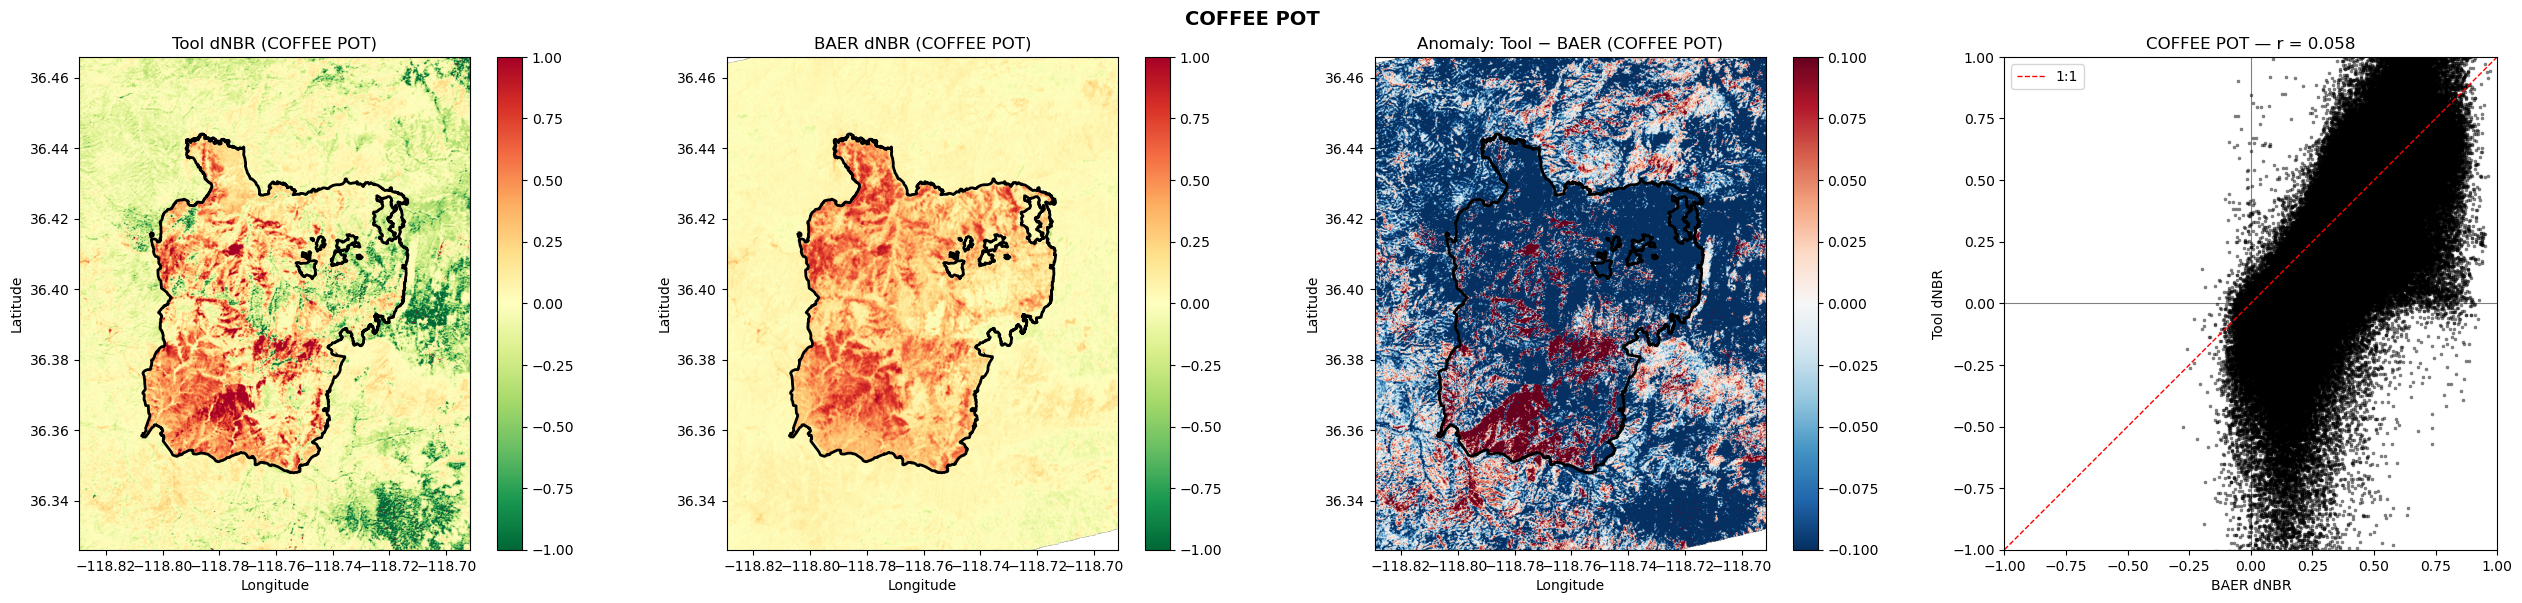

DOME: job is 'failed', skipping.


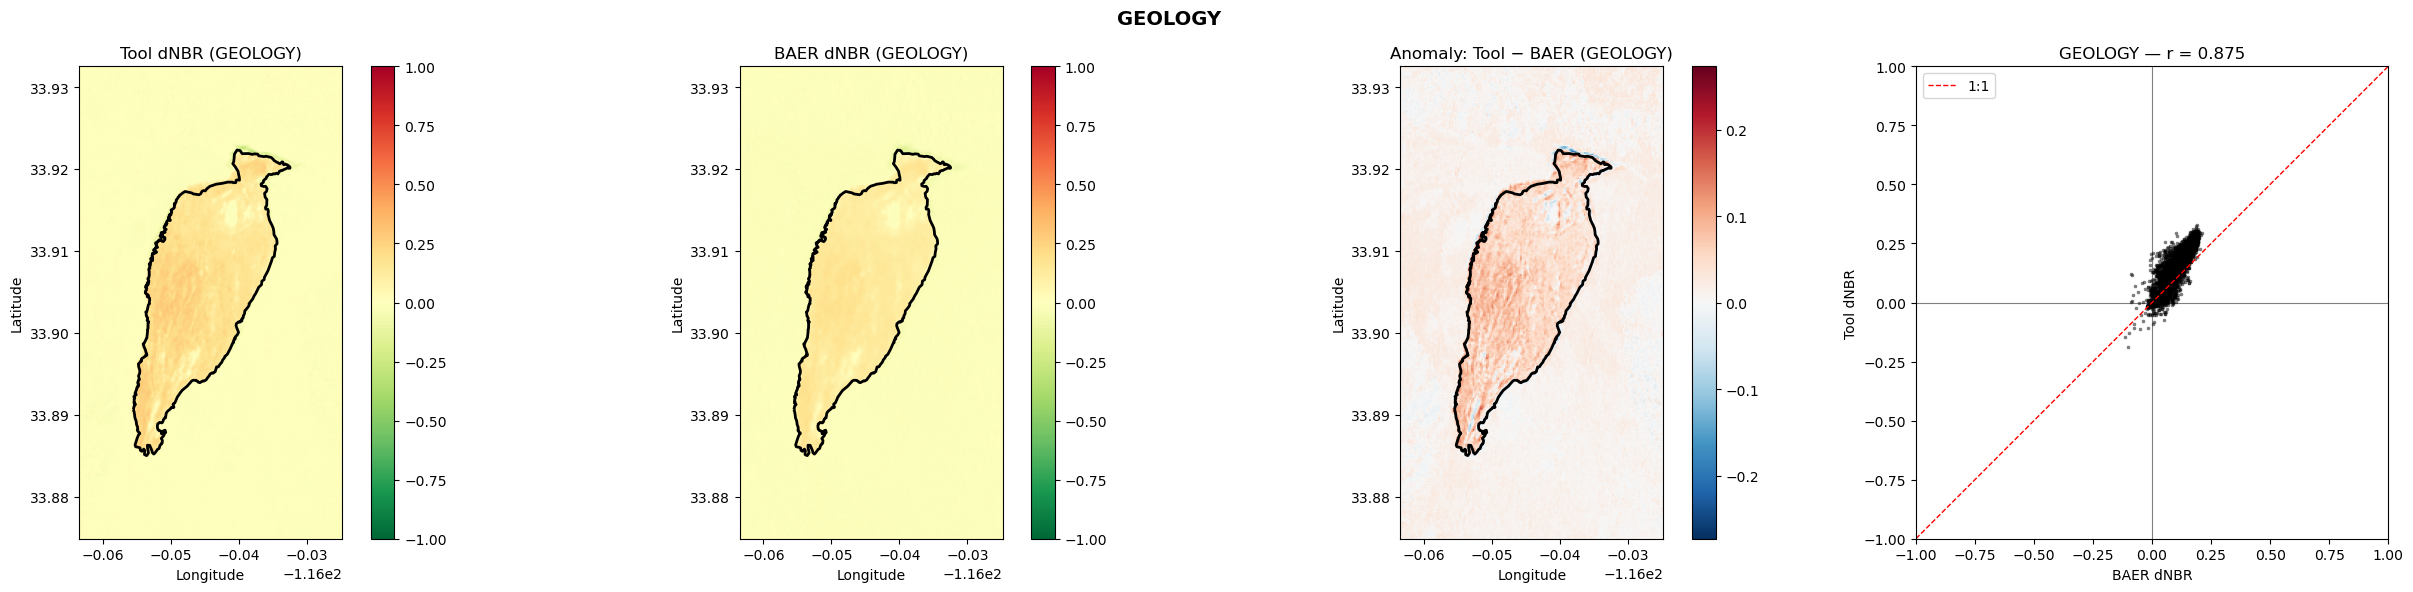

KNP Complex: job is 'pending', skipping.


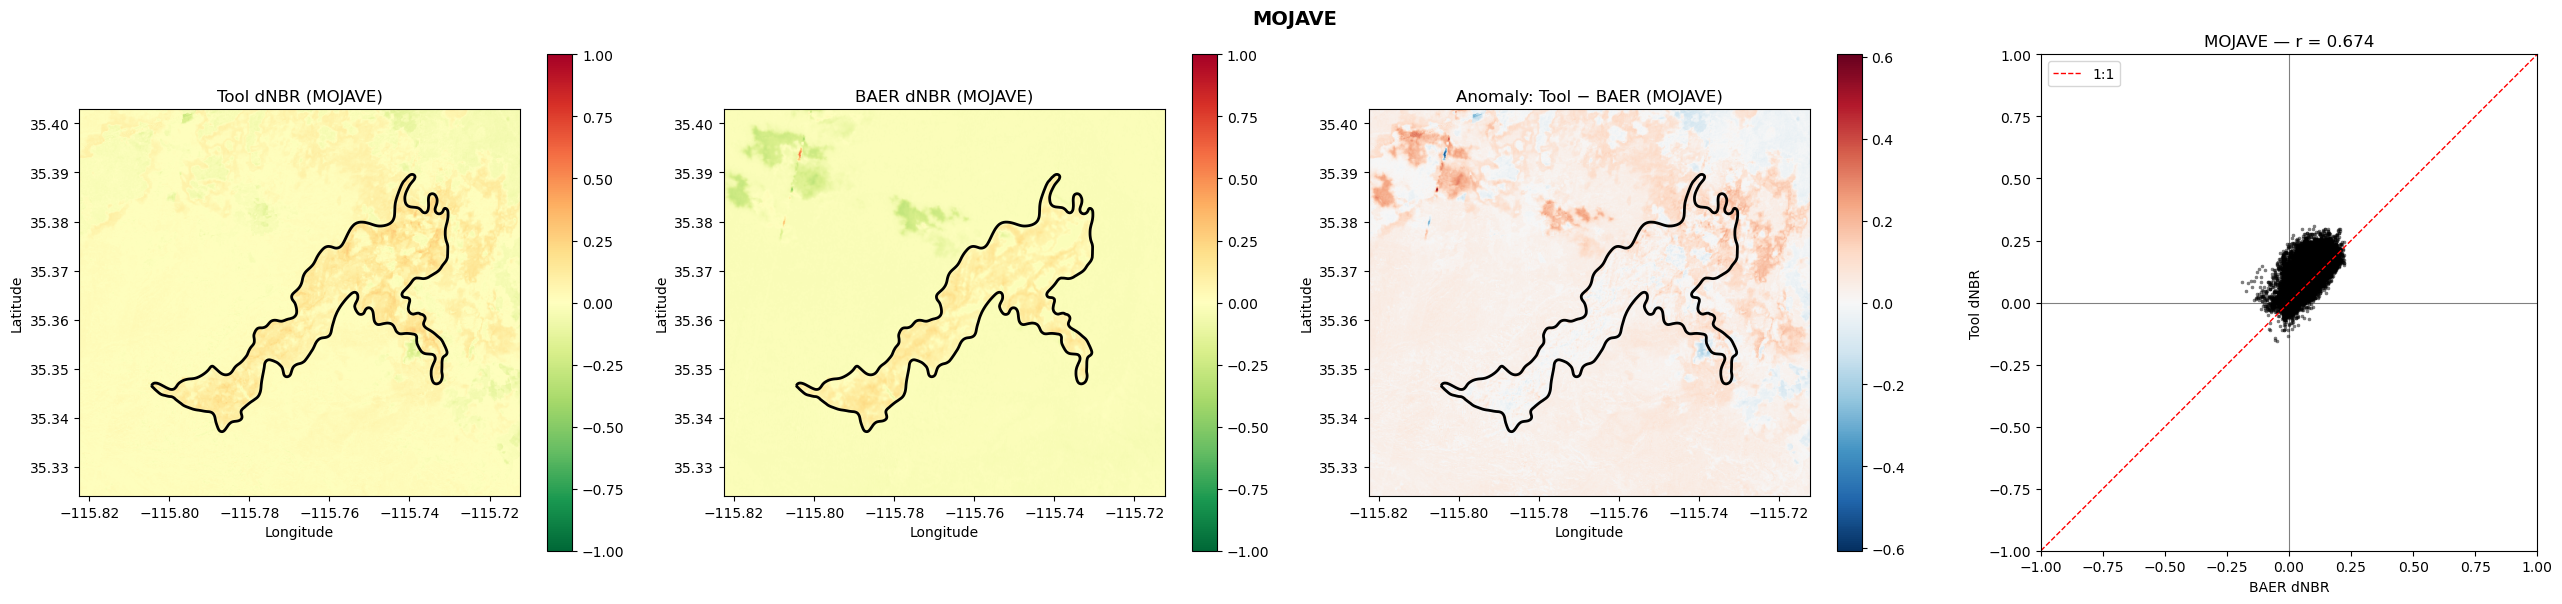

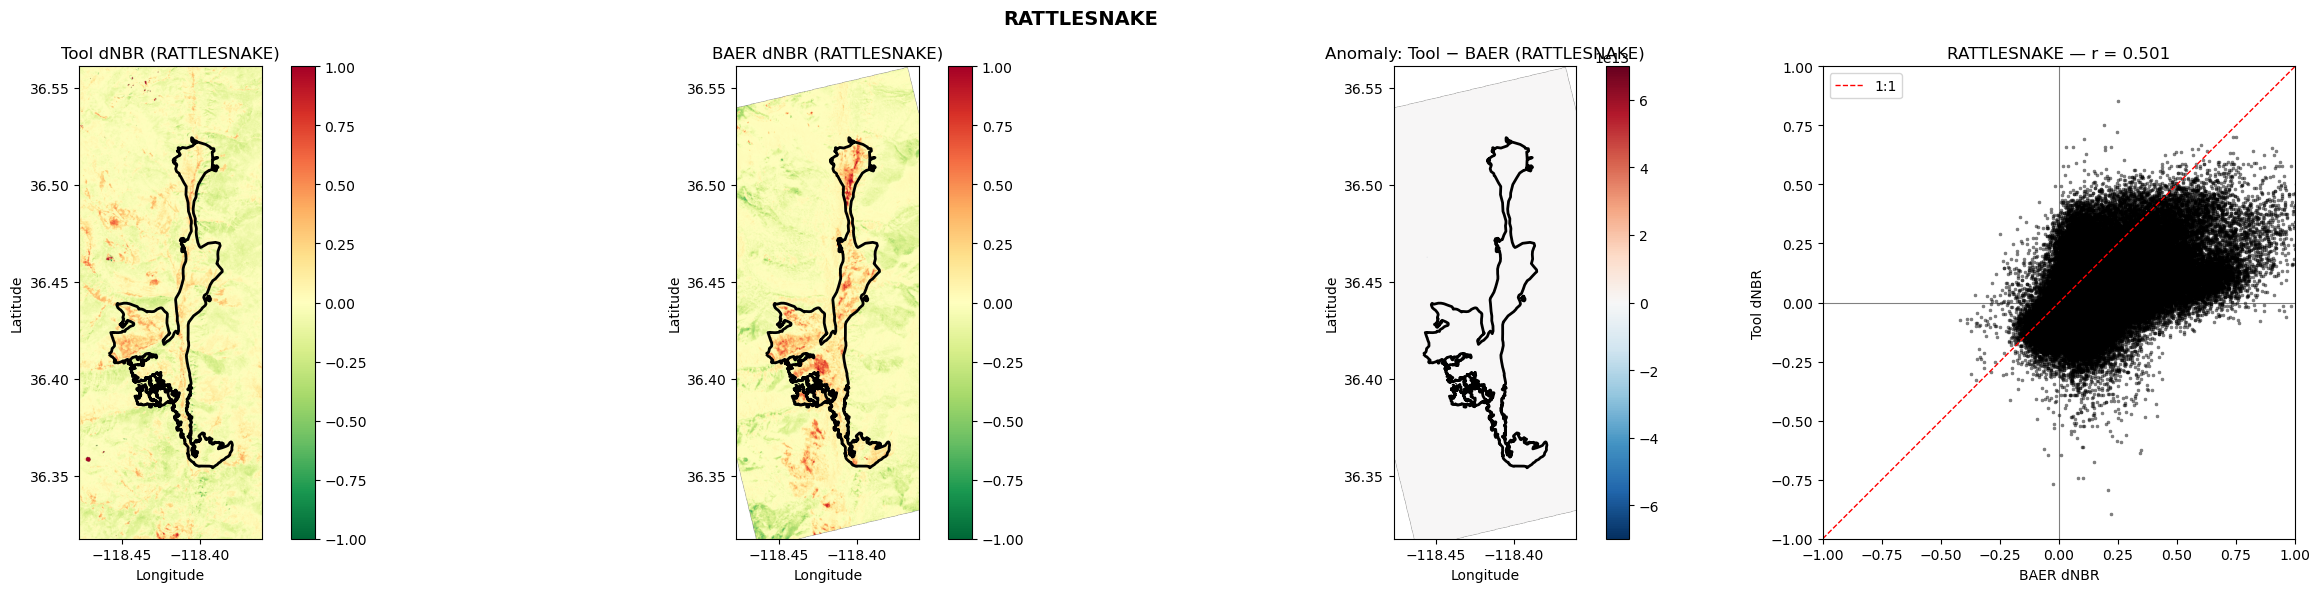


REDWOOD: ERROR — No data found in bounds.


Traceback (most recent call last):
  File "/var/folders/c4/x2rq5kz521nfv7p751bkt5c00000gn/T/ipykernel_1886/2150210836.py", line 35, in <module>
    baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, tool_raster) / 1000
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/c4/x2rq5kz521nfv7p751bkt5c00000gn/T/ipykernel_1886/2979210077.py", line 9, in make_baer_like_tool_raster
    baer_raster = baer_raster.rio.clip_box(*tool_raster.rio.bounds())
  File "/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/rioxarray/raster_array.py", line 866, in clip_box
    raise NoDataInBounds(
        f"No data found in bounds.{_get_data_var_message(self._obj)}"
    )
rioxarray.exceptions.NoDataInBounds: No data found in bounds.


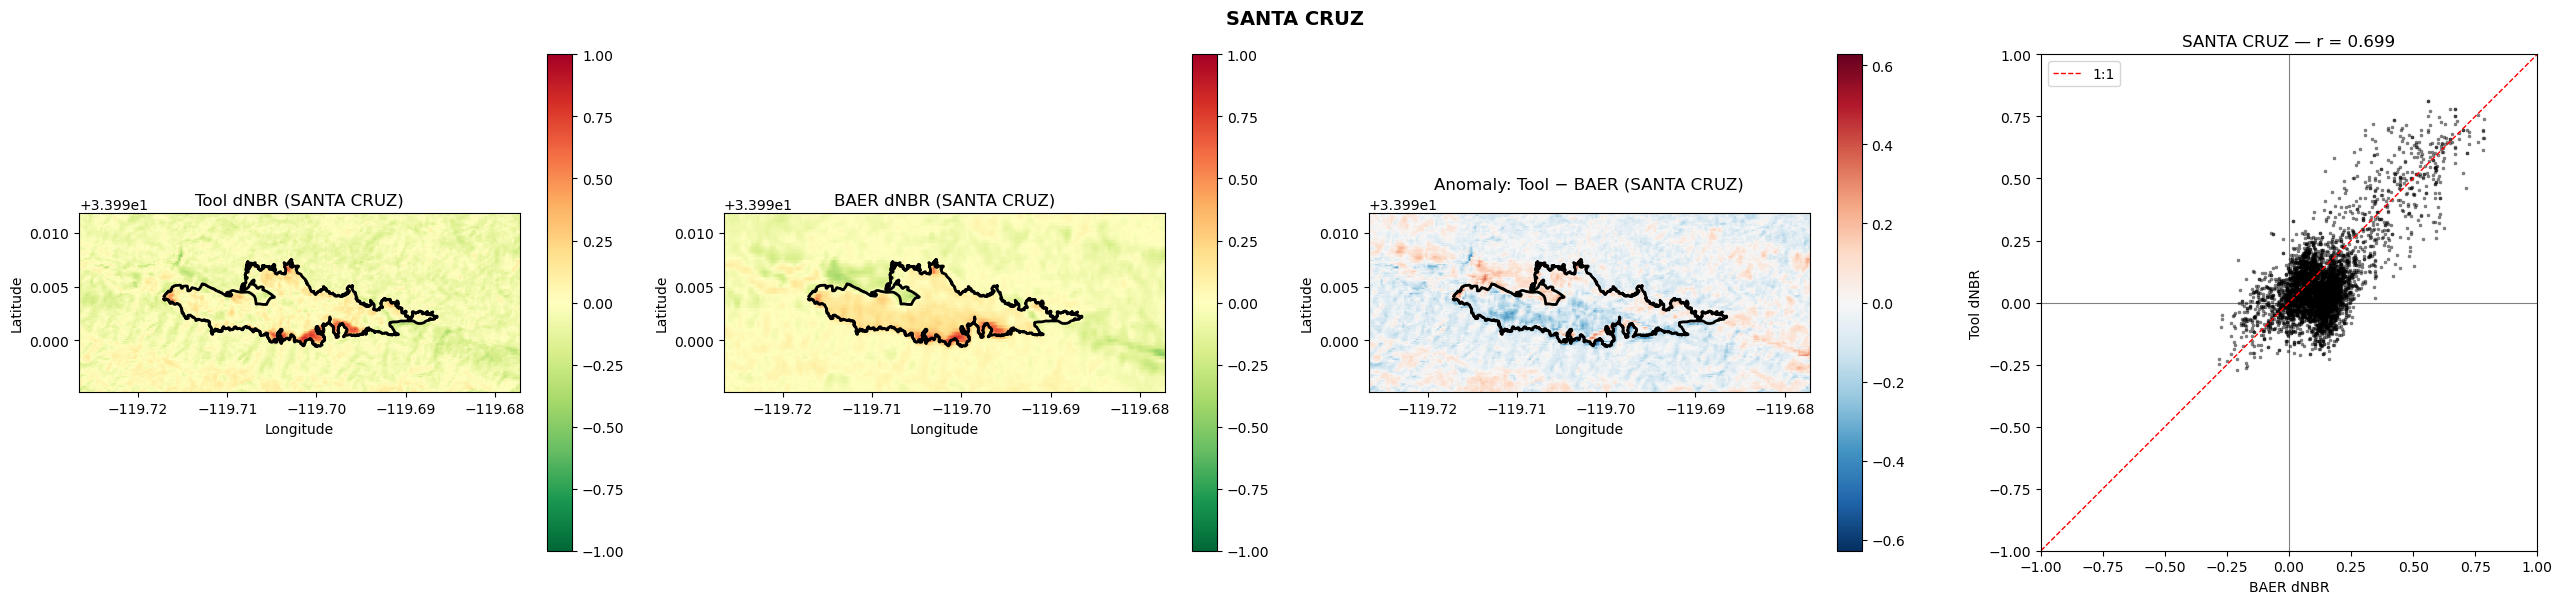

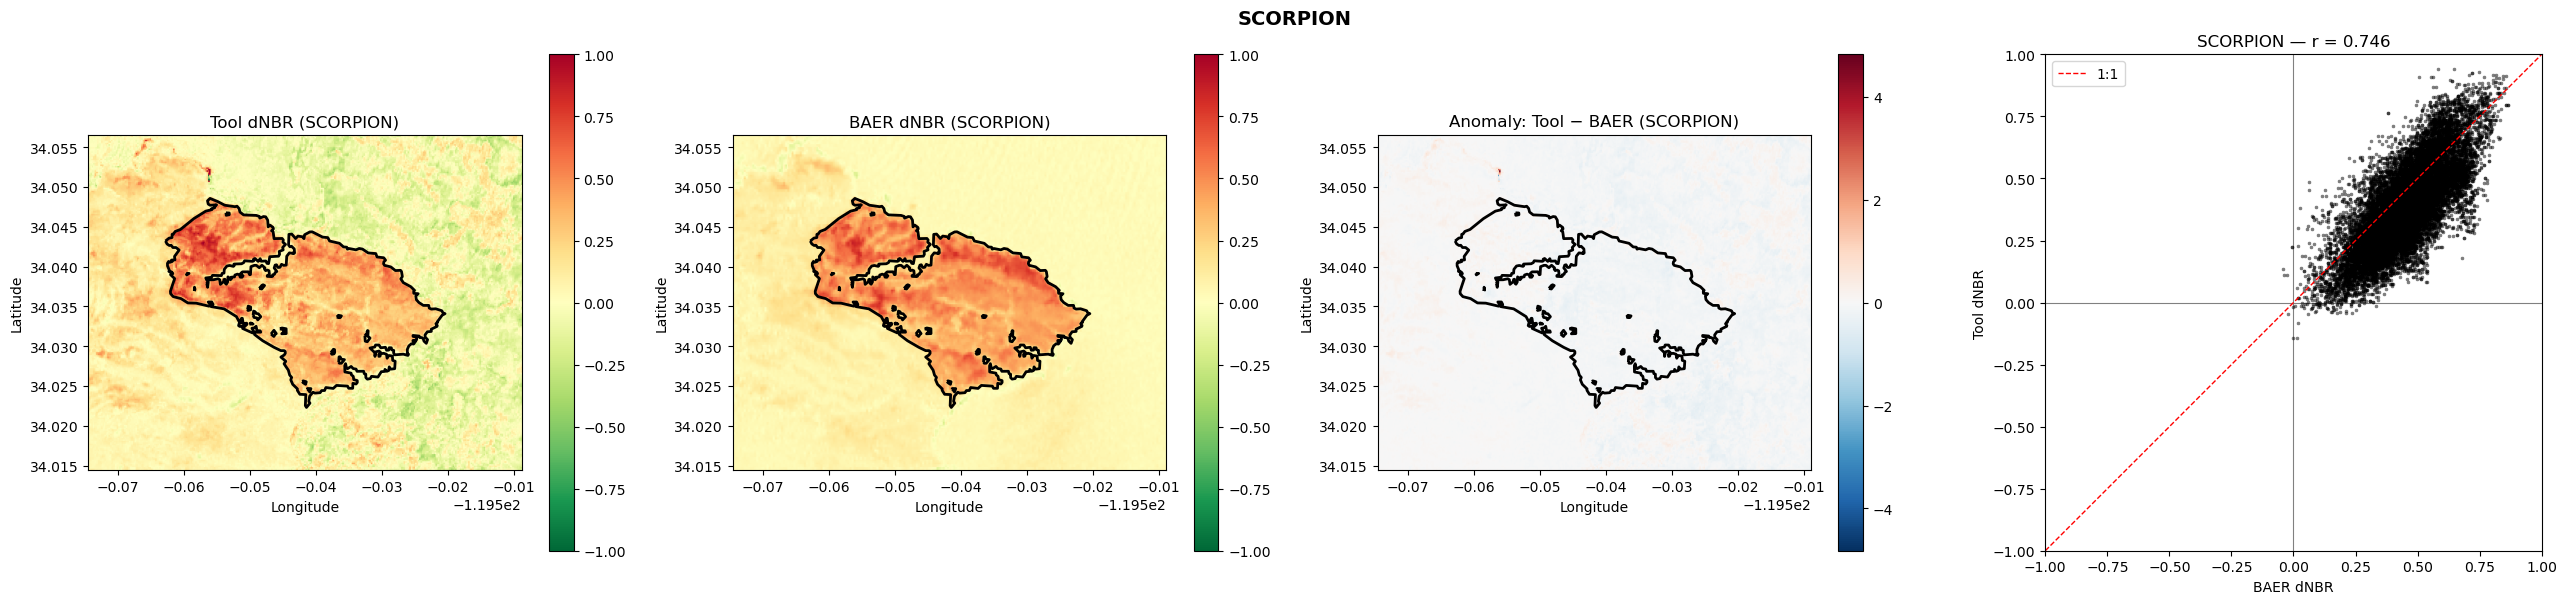

YORK: job is 'failed', skipping.


,fire_name,pearson_r
0,COFFEE POT,0.0579
1,GEOLOGY,0.8747
2,MOJAVE,0.6744
3,RATTLESNAKE,0.5008
4,SANTA CRUZ,0.6993
5,SCORPION,0.7457


In [103]:
import traceback

results = []

for _, baer_row in baer_data_list.iterrows():
    fire_name = baer_row['fire_name']

    try:
        job_rows = fire_jobs[
            (fire_jobs['fire_name'] == fire_name) &
            (fire_jobs['date_mode'] == 'alarm') &
            (fire_jobs['post_fire_days'] == 60)
        ]
        if job_rows.empty:
            print(f"{fire_name}: no matching job found, skipping.")
            continue

        fire_event_name = job_rows['fire_event_name'].values[0]
        job_id = job_rows['job_id'].values[0]

        response = requests.get(
            f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app"
            f"/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}"
        )
        response_data = response.json()

        if response_data.get('status') != 'complete':
            print(f"{fire_name}: job is '{response_data.get('status')}', skipping.")
            continue

        dnbr_url = response_data.get('coarse_severity_cog_urls', {}).get('dnbr')
        calfire_boundary = calfire_boundaries[calfire_boundaries['FIRE_NAME'] == fire_name]

        tool_raster = rxr.open_rasterio(dnbr_url)
        baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, tool_raster) / 1000

        correlation = plot_fire_comparison(fire_name, tool_raster, baer_raster, calfire_boundary)
        results.append({'fire_name': fire_name, 'pearson_r': round(correlation, 4)})

    except Exception as e:
        print(f"\n{fire_name}: ERROR — {e}")
        traceback.print_exc()
        continue

results_df = pd.DataFrame(results)
results_df.to_csv('dnbr_correlation_results.csv', index=False)
results_df
